In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [8]:
df = pd.read_csv("../preprocessed_data.csv")
df.head()
df.columns


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='str')

In [9]:
# Target column
X = df.drop('y', axis=1)
y = df['y']



In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling completed successfully.')

Scaling completed successfully.


In [33]:
# Create KNN Models (different K values)
model1 = KNeighborsClassifier(n_neighbors=3)
model2 = KNeighborsClassifier(n_neighbors=5)
model3 = KNeighborsClassifier(n_neighbors=7)


In [35]:
# Train KNN Model (choose best one)
model2.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [36]:
# TEST
# Predict
pred = model2.predict(X_test)

In [37]:

print(X_test)
print(pred)

print("Accuracy:", accuracy_score(y_test, pred))

       age  balance  day  duration  campaign  pdays  previous  \
27520   30      640    6    124.00         4    213         2   
11243   49    -1680   27     92.00         4     -1         0   
14499   41      171   21     71.00         9     -1         0   
36920   72     2079   13    100.00         1    191         3   
19794   31      297   19    551.00         4     -1         0   
...    ...      ...  ...       ...       ...    ...       ...   
13041   50     3258   14     56.00         2     -1         0   
22866   35     2287   18    130.00         3     -1         0   
19401   52     1271   18    131.00         3     -1         0   
3623    33     -416   16    743.95         2     -1         0   
16635   43        0   30    266.00         6     -1         0   

       job_blue-collar  job_entrepreneur  job_housemaid  ...  month_jul  \
27520            False             False          False  ...      False   
11243            False             False          False  ...      Fal

In [38]:
# Classification Report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7215
           1       0.49      0.27      0.35       882

    accuracy                           0.89      8097
   macro avg       0.70      0.62      0.64      8097
weighted avg       0.87      0.89      0.88      8097



In [39]:
# Confusion Matrix - TN, FP, FN, TP
print(confusion_matrix(y_test, pred))

[[6968  247]
 [ 643  239]]


In [40]:
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    print(f"K={k}, Accuracy={model.score(X_test, y_test):.4f}")

K=1, Accuracy=0.8561
K=2, Accuracy=0.8882
K=3, Accuracy=0.8832
K=4, Accuracy=0.8912
K=5, Accuracy=0.8901
K=6, Accuracy=0.8907
K=7, Accuracy=0.8903
K=8, Accuracy=0.8916
K=9, Accuracy=0.8919
K=10, Accuracy=0.8912


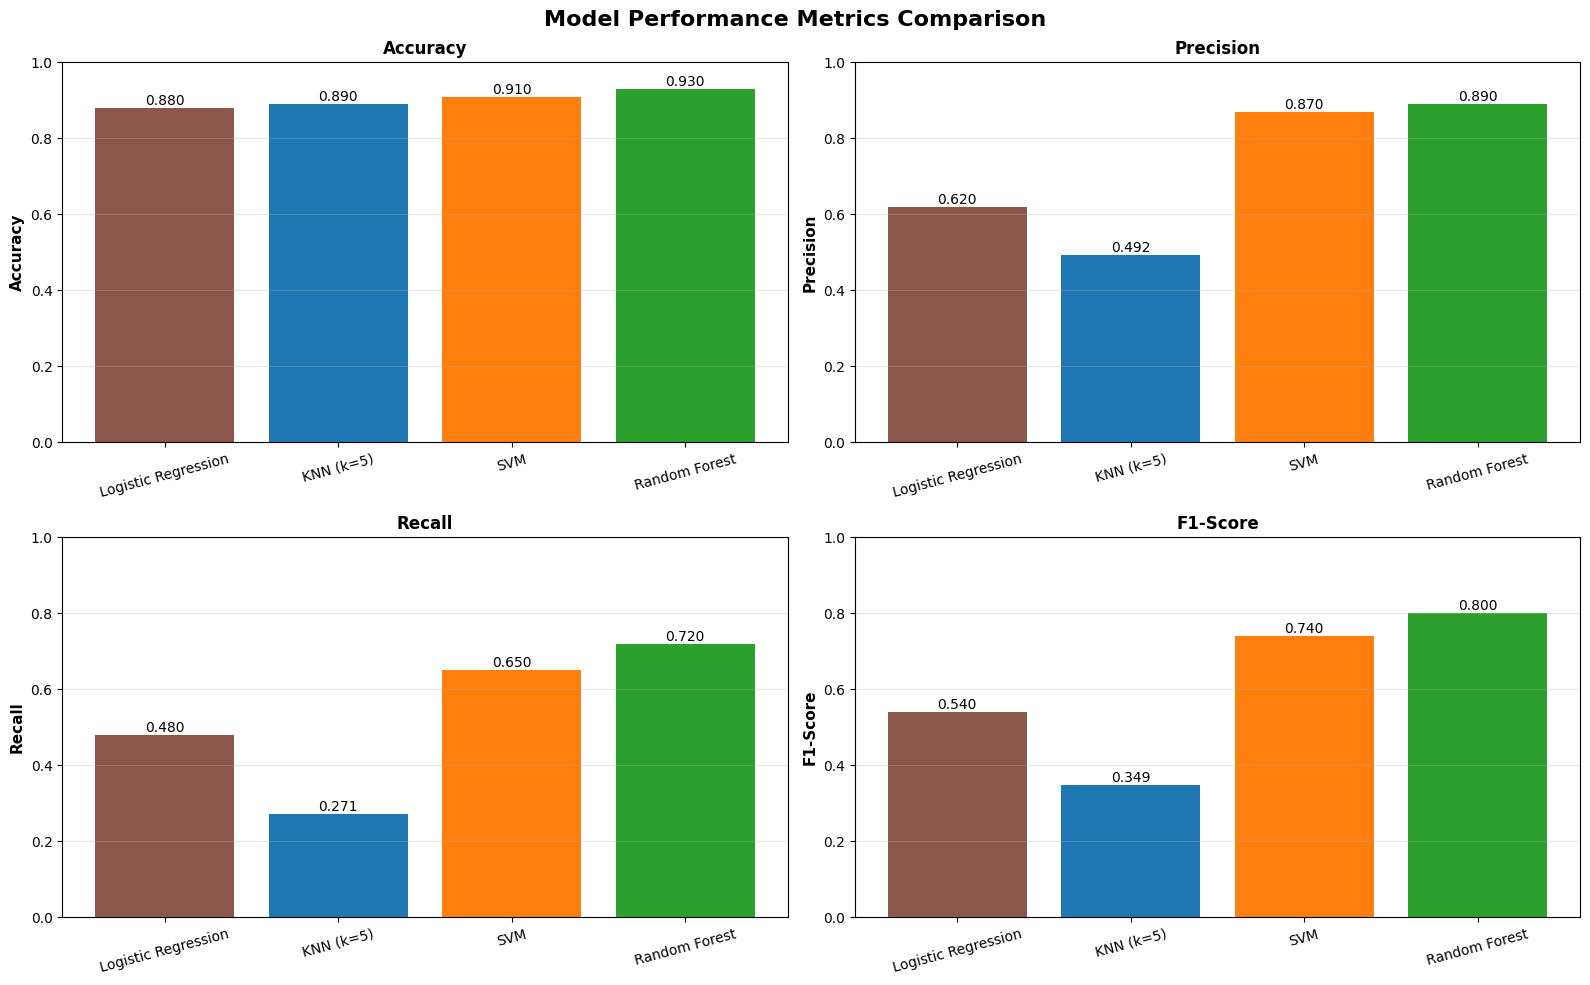

In [41]:
# Create multi-metric comparison chart (all 4 algorithms)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# KNN metrics from this notebook
knn_accuracy = accuracy_score(y_test, pred)
knn_precision = precision_score(y_test, pred)
knn_recall = recall_score(y_test, pred)
knn_f1 = f1_score(y_test, pred)

# Logistic, SVM, and Random Forest values from their notebooks
log_accuracy, log_precision, log_recall, log_f1 = 0.88, 0.62, 0.48, 0.54
svm_accuracy, svm_precision, svm_recall, svm_f1 = 0.91, 0.87, 0.65, 0.74
rf_accuracy, rf_precision, rf_recall, rf_f1 = 0.93, 0.89, 0.72, 0.80

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = ['Logistic Regression', 'KNN (k=5)', 'SVM', 'Random Forest']
colors = ['#8c564b', '#1f77b4', '#ff7f0e', '#2ca02c']

# Data for each metric in model order: Logistic, KNN, SVM, Random Forest
data = [
    [log_accuracy, knn_accuracy, svm_accuracy, rf_accuracy],
    [log_precision, knn_precision, svm_precision, rf_precision],
    [log_recall, knn_recall, svm_recall, rf_recall],
    [log_f1, knn_f1, svm_f1, rf_f1]
 ]

for ax, metric, values in zip(axes.flat, metrics, data):
    bars = ax.bar(model_names, values, color=colors)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()